In [2]:
import pandas as pd
import os


PATH = "/scratch/am10150/projects/rtcloud-projects/mindeye/3t/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/train_data_scaling-ses1-2_v2"
folders = os.listdir(PATH)
metrics_dfs = []
for folder in folders:
    print(folder)
    data_size = int(folder.split("sample=")[1].split("_")[0])
    data_size = data_size * 10
    
    metrics = pd.read_csv(os.path.join(PATH, folder, "0", "metrics.csv"))
    metrics = metrics[metrics['category'] == 'rep']
    metrics['data_size'] = data_size
    metrics_dfs.append(metrics)
    

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=6_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=8_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=9_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=3_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=5_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=10_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=2_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=7_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=1_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=4_avgrepeats_finalmask_epochs_150_delay=0


In [3]:
metrics_all = pd.concat(metrics_dfs)

In [4]:
METRICS = [
    'all_fwd_acc',
    'all_bwd_acc',
    'pixcorr',
    'ssim',
    'alexnet2',
    'alexnet5',
    'inception',
    'clip',
    'efficientnet',
    'swav',
]
metrics_all.groupby("data_size")[METRICS].mean()
# metrics_all.groupby('data_size').mean()

,all_fwd_acc,all_bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip,efficientnet,swav
data_size,,,,,,,,,,
10,0.253333,0.133333,0.044591,0.313243,0.671837,0.688435,0.587755,0.563265,0.957349,0.611257
20,0.313333,0.306667,0.074888,0.334486,0.724490,0.760136,0.637143,0.605850,0.942208,0.586098
30,0.426667,0.346667,0.092696,0.337525,0.769252,0.805986,0.653333,0.617007,0.917806,0.570412
40,0.480000,0.420000,0.087706,0.336995,0.756190,0.790748,0.671429,0.627755,0.916268,0.569332
50,0.486667,0.493333,0.084493,0.337696,0.750884,0.784490,0.646803,0.636190,0.908159,0.561788
60,0.546667,0.506667,0.098738,0.346319,0.752517,0.774150,0.655238,0.648027,0.910088,0.560357
70,0.540000,0.566667,0.087445,0.342055,0.771293,0.797415,0.665986,0.637143,0.916944,0.568924
80,0.573333,0.533333,0.099612,0.361504,0.754286,0.799456,0.712925,0.638503,0.918884,0.569845
90,0.566667,0.553333,0.095598,0.332224,0.777415,0.812245,0.726259,0.632245,0.917421,0.574643


<Figure size 1000x600 with 0 Axes>

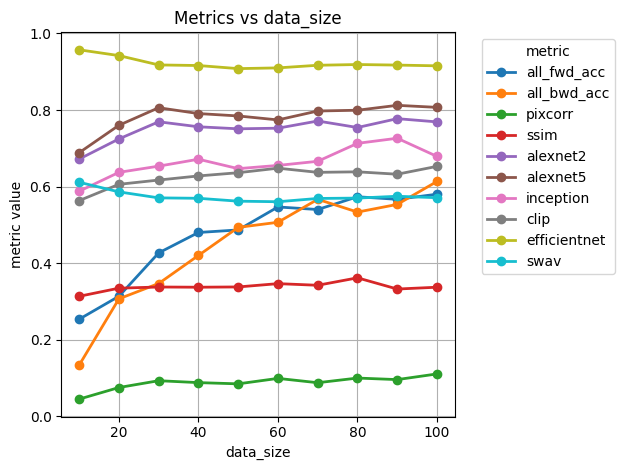

In [5]:
agg = metrics_all.groupby("data_size")[METRICS].mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
agg.plot(marker='o', linewidth=2)
plt.xlabel('data_size')
plt.ylabel('metric value')
plt.title('Metrics vs data_size')
plt.grid(True)
plt.legend(title='metric', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
metric_maxs = {
}
agg_ri = agg.reset_index().copy()
for metric in METRICS:
    metric_max = agg_ri[metric].max()
    agg_ri[metric] = agg_ri[metric].apply(lambda x: x / metric_max)


In [10]:
agg_ri

,data_size,all_fwd_acc,all_bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip,efficientnet,swav
0,10,0.436782,0.217391,0.403904,0.866499,0.864193,0.847571,0.809292,0.862860,1.000000,1.000000
1,20,0.540230,0.500000,0.678332,0.925264,0.931922,0.935846,0.877295,0.928095,0.984184,0.958841
2,30,0.735632,0.565217,0.839634,0.933669,0.989499,0.992295,0.899588,0.945185,0.958695,0.933179
3,40,0.827586,0.684783,0.794438,0.932204,0.972699,0.973534,0.924504,0.961651,0.957088,0.931413
4,50,0.839080,0.804348,0.765333,0.934142,0.965873,0.965829,0.890596,0.974573,0.948619,0.919071
5,60,0.942529,0.826087,0.894370,0.957996,0.967973,0.953099,0.902211,0.992705,0.950633,0.916730
6,70,0.931034,0.923913,0.792072,0.946201,0.992125,0.981742,0.917010,0.976032,0.957794,0.930745
7,80,0.988506,0.869565,0.902286,1.000000,0.970249,0.984255,0.981641,0.978116,0.959821,0.932252
8,90,0.977011,0.902174,0.865920,0.919006,1.000000,1.000000,1.000000,0.968529,0.958293,0.940101
9,100,1.000000,1.000000,1.000000,0.932164,0.989149,0.993467,0.934620,1.000000,0.956273,0.933945


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
agg.plot(marker='o', linewidth=2)
plt.xlabel('data_size')
plt.ylabel('metric value')
plt.title('Metrics vs data_size')
plt.grid(True)
plt.legend(title='metric', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()